<a href="https://colab.research.google.com/github/vsanthosh200508-poker/Portfolio/blob/main/Cognifyz_Internship_projectColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍽️ Cognifyz Technologies — Data Science Internship
### Name: V Santhosh | Ref: CTI/A1/C333212
---
**Dataset:** Restaurant data with 9,551 rows and 21 columns

| Level | Tasks |
|-------|-------|
| Level 1 | Data Exploration, Descriptive Analysis, Geospatial Analysis |
| Level 2 | Table Booking & Delivery, Price Range Analysis, Feature Engineering |
| Level 3 | Predictive Modeling, Customer Preference, Data Visualization |

## ⚙️ Step 0 — Install & Import Libraries

In [ ]:
# Install libraries (only needed in Colab)
!pip install folium -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 1 — Upload & Load the Dataset
> **Upload your `Dataset_.csv` file when prompted below**

In [ ]:
from google.colab import files
uploaded = files.upload()  # Upload your Dataset_.csv here

Saving Dataset .csv to Dataset .csv


In [ ]:
# Load the dataset
df = pd.read_csv('Dataset .csv', encoding='utf-8-sig')

print(f'✅ Dataset loaded!')
print(f'📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded!
📊 Shape: 9551 rows × 21 columns


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


---
# 🟡 LEVEL 1 — Data Exploration, Descriptive & Geospatial Analysis

## 📌 Level 1 — Task 1: Data Exploration & Preprocessing

In [ ]:
# ── 1.1 Basic Info
print('=== DATASET INFO ===')
print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
print()
df.info()

=== DATASET INFO ===
Rows   : 9551
Columns: 21

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     95

In [ ]:
# ── 1.2 Check Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

print('=== MISSING VALUES ===')
if len(missing_df) == 0:
    print('No missing values! ✅')
else:
    print(missing_df)

print(f'\nTotal Missing: {df.isnull().sum().sum()}')
print(f'Duplicate Rows: {df.duplicated().sum()}')

=== MISSING VALUES ===
          Missing Count  Missing %
Cuisines              9       0.09

Total Missing: 9
Duplicate Rows: 0


In [ ]:
# ── 1.3 Handle Missing Values
df['Cuisines'].fillna('Unknown', inplace=True)
print('✅ Missing values in Cuisines filled with "Unknown"')
print(f'Missing values remaining: {df.isnull().sum().sum()}')

✅ Missing values in Cuisines filled with "Unknown"
Missing values remaining: 0


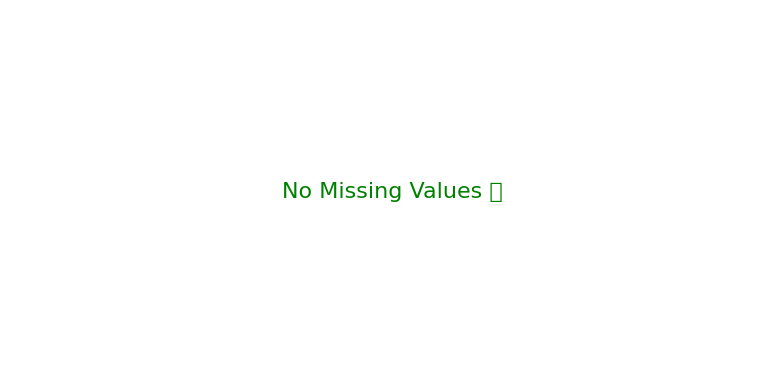

In [ ]:
# ── 1.4 Visualize Missing Values
fig, ax = plt.subplots(figsize=(8, 4))
mv = df.isnull().sum()
mv = mv[mv > 0]
if len(mv) > 0:
    mv.plot(kind='bar', color='salmon', ax=ax)
    ax.set_title('Missing Values per Column', fontsize=14)
    ax.set_xlabel('Column')
    ax.set_ylabel('Missing Count')
else:
    ax.text(0.5, 0.5, 'No Missing Values ✅', ha='center', va='center', fontsize=16, color='green')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 📌 Level 1 — Task 2: Descriptive Analysis

In [ ]:
# ── 2.1 Statistical Summary
print('=== STATISTICAL SUMMARY ===')
df[['Average Cost for two', 'Aggregate rating', 'Votes']].describe().round(2)

=== STATISTICAL SUMMARY ===


,Average Cost for two,Aggregate rating,Votes
count,9551.00,9551.00,9551.00
mean,1199.21,2.67,156.91
std,16121.18,1.52,430.17
min,0.00,0.00,0.00
25%,250.00,2.50,5.00
50%,400.00,3.20,31.00
75%,700.00,3.70,131.00
max,800000.00,4.90,10934.00


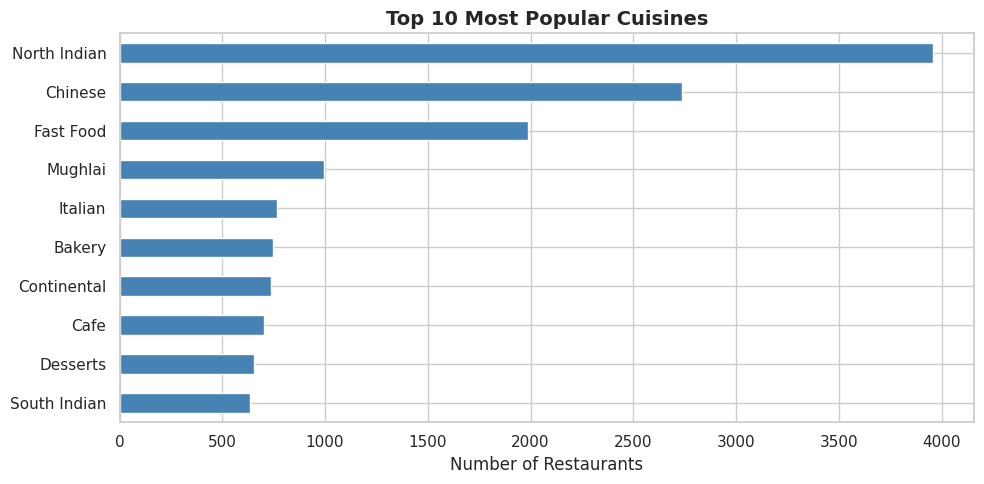

North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636


In [ ]:
# ── 2.2 Top 10 Cuisines
all_cuisines = [c for sub in df['Cuisines'].dropna().str.split(', ') for c in sub]
top_cuisines = pd.Series(Counter(all_cuisines)).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_cuisines.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 10 Most Popular Cuisines', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.tight_layout()
plt.show()

print(top_cuisines.to_string())

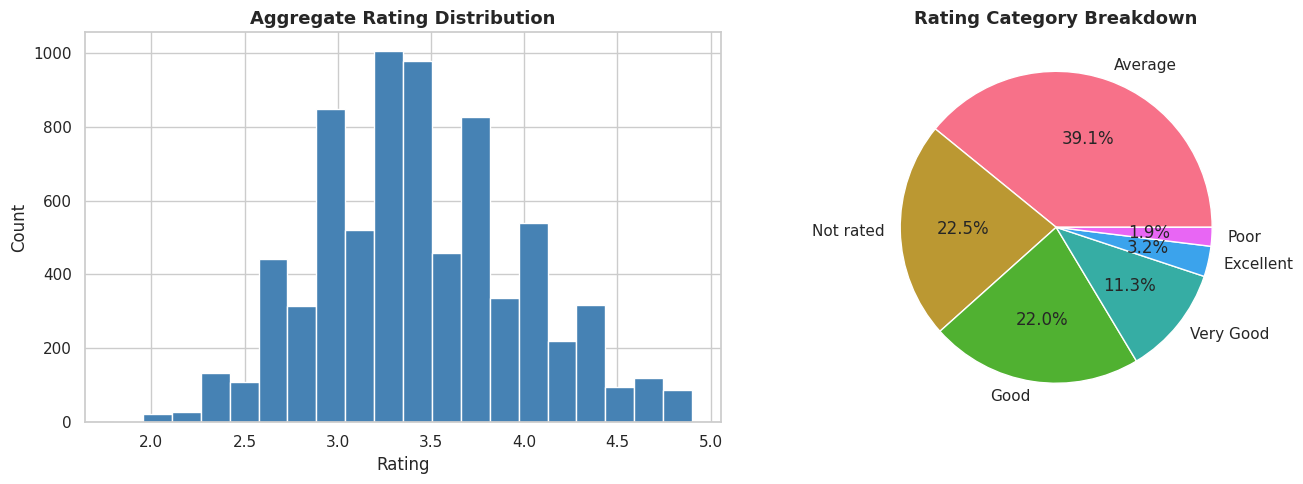

Rating Distribution:
Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186


In [ ]:
# ── 2.3 Rating Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
df[df['Aggregate rating'] > 0]['Aggregate rating'].hist(
    bins=20, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Aggregate Rating Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Rating text pie
rating_counts = df['Rating text'].value_counts()
axes[1].pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('husl', len(rating_counts)))
axes[1].set_title('Rating Category Breakdown', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('Rating Distribution:')
print(df['Rating text'].value_counts().to_string())

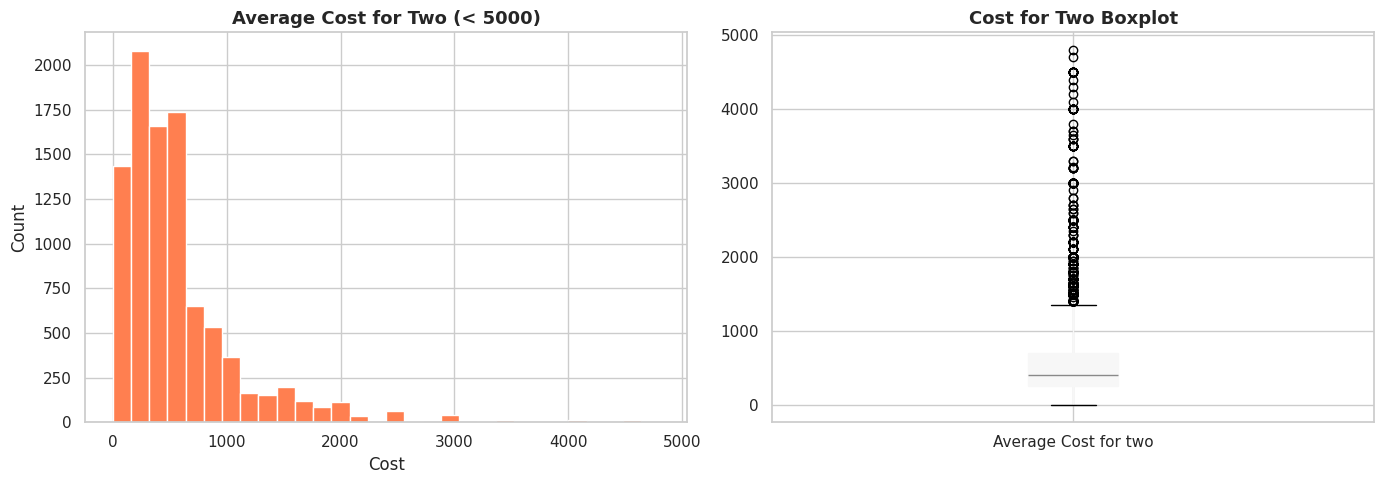

In [ ]:
# ── 2.4 Average Cost Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_cost = df[df['Average Cost for two'] < 5000]
df_cost['Average Cost for two'].hist(bins=30, color='coral', edgecolor='white', ax=axes[0])
axes[0].set_title('Average Cost for Two (< 5000)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cost')
axes[0].set_ylabel('Count')

df_cost.boxplot(column='Average Cost for two', ax=axes[1], patch_artist=True)
axes[1].set_title('Cost for Two Boxplot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 📌 Level 1 — Task 3: Geospatial Analysis

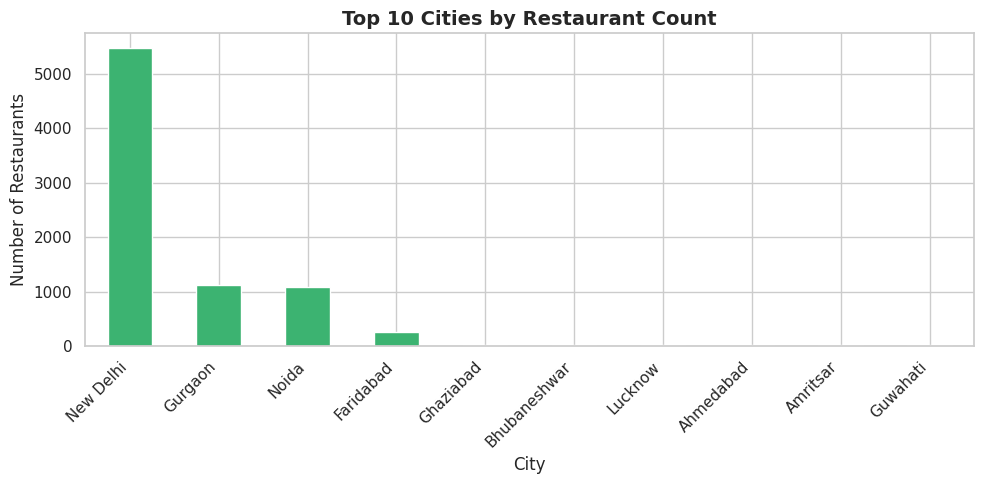

Top 5 Cities:
City
New Delhi    5473
Gurgaon      1118
Noida        1080
Faridabad     251
Ghaziabad      25


In [ ]:
# ── 3.1 Top Cities
top_cities = df['City'].value_counts().head(10)
plt.figure(figsize=(10, 5))
top_cities.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Top 10 Cities by Restaurant Count', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 5 Cities:')
print(top_cities.head().to_string())

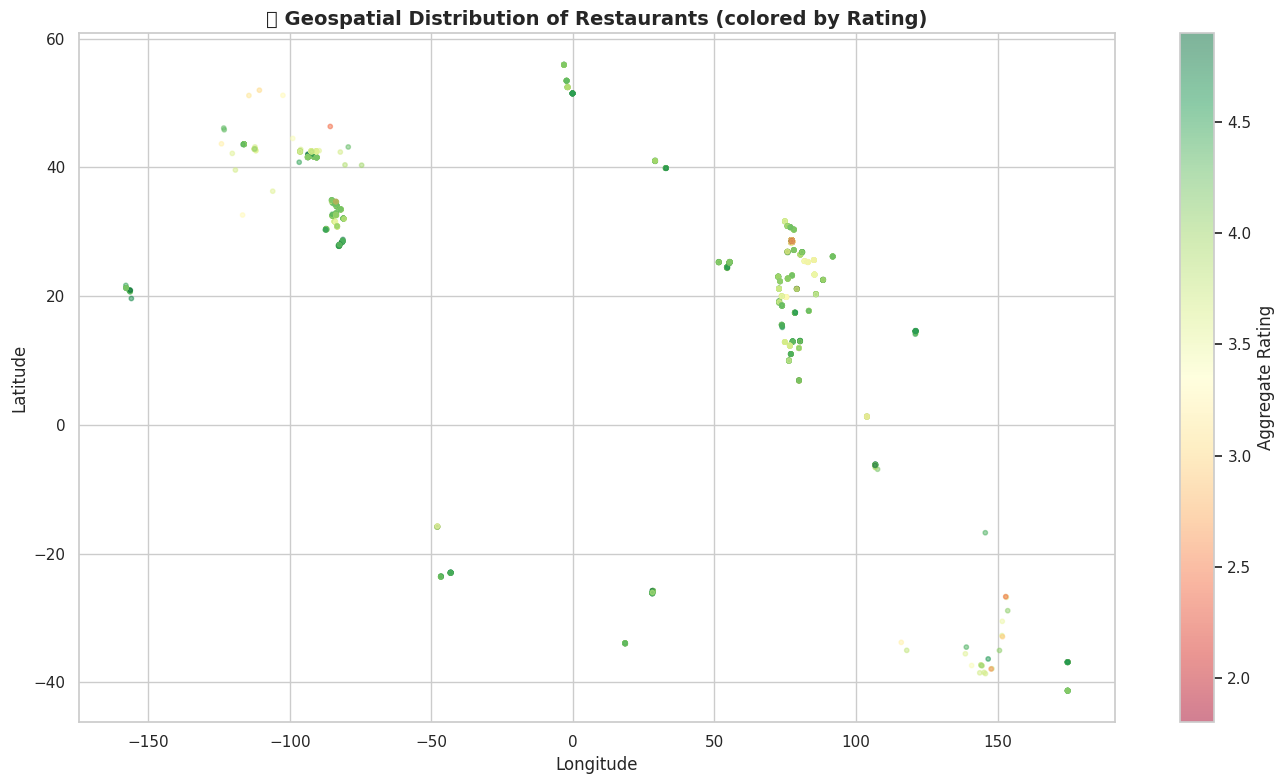

In [ ]:
# ── 3.2 Geospatial Scatter Plot (Matplotlib)
df_geo = df[(df['Longitude'] != 0) & (df['Latitude'] != 0) & (df['Aggregate rating'] > 0)]

plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    df_geo['Longitude'], df_geo['Latitude'],
    c=df_geo['Aggregate rating'], cmap='RdYlGn',
    alpha=0.5, s=10
)
plt.colorbar(scatter, label='Aggregate Rating')
plt.title('🌍 Geospatial Distribution of Restaurants (colored by Rating)', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

In [ ]:
# ── 3.3 Interactive Map with Folium (Top 500 restaurants)
df_map = df_geo.head(500)

m = folium.Map(location=[df_map['Latitude'].mean(), df_map['Longitude'].mean()], zoom_start=5)

def get_color(rating):
    if rating >= 4.5: return 'darkgreen'
    elif rating >= 4.0: return 'green'
    elif rating >= 3.5: return 'lightgreen'
    elif rating >= 3.0: return 'orange'
    else: return 'red'

for _, row in df_map.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=5,
        color=get_color(row['Aggregate rating']),
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['Restaurant Name']}</b><br>"
            f"City: {row['City']}<br>"
            f"Rating: {row['Aggregate rating']}<br>"
            f"Cuisine: {row['Cuisines']}",
            max_width=200
        )
    ).add_to(m)

m  # Display interactive map in Colab

---
# 🟠 LEVEL 2 — Table Booking, Price Range & Feature Engineering

## 📌 Level 2 — Task 1: Table Booking & Online Delivery

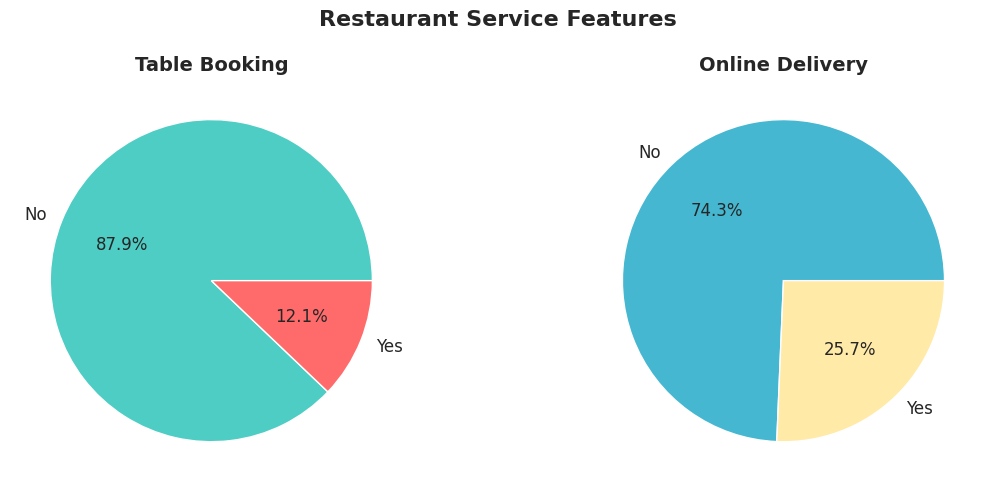

Table Booking:
Has Table booking
No     87.88
Yes    12.12

Online Delivery:
Has Online delivery
No     74.34
Yes    25.66


In [ ]:
# ── 4.1 Percentage with Table Booking and Online Delivery
tb_pct = df['Has Table booking'].value_counts(normalize=True) * 100
od_pct = df['Has Online delivery'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(tb_pct, labels=tb_pct.index, autopct='%1.1f%%',
            colors=['#4ECDC4', '#FF6B6B'], textprops={'fontsize': 12})
axes[0].set_title('Table Booking', fontsize=14, fontweight='bold')

axes[1].pie(od_pct, labels=od_pct.index, autopct='%1.1f%%',
            colors=['#45B7D1', '#FFEAA7'], textprops={'fontsize': 12})
axes[1].set_title('Online Delivery', fontsize=14, fontweight='bold')

plt.suptitle('Restaurant Service Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Table Booking:\n{tb_pct.round(2).to_string()}\n')
print(f'Online Delivery:\n{od_pct.round(2).to_string()}')

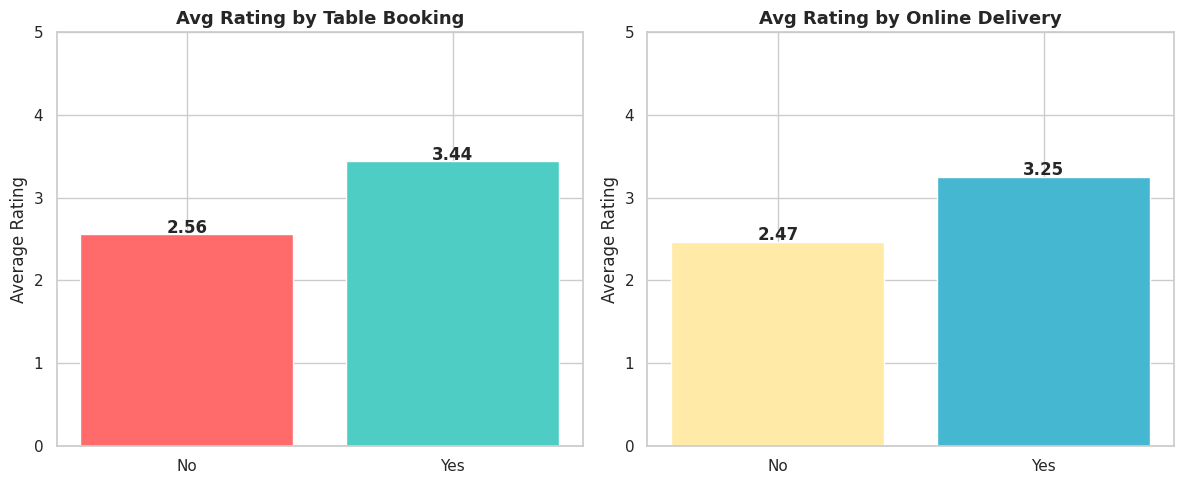

Key Insight: Restaurants with Table Booking/Online Delivery have HIGHER ratings!


In [ ]:
# ── 4.2 Avg Rating by Table Booking & Online Delivery
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

tb_rating = df.groupby('Has Table booking')['Aggregate rating'].mean()
bars1 = axes[0].bar(tb_rating.index, tb_rating.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='white')
for b in bars1:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                 f'{b.get_height():.2f}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Avg Rating by Table Booking', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(0, 5)

od_rating = df.groupby('Has Online delivery')['Aggregate rating'].mean()
bars2 = axes[1].bar(od_rating.index, od_rating.values, color=['#FFEAA7', '#45B7D1'], edgecolor='white')
for b in bars2:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
                 f'{b.get_height():.2f}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Avg Rating by Online Delivery', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.show()

print('Key Insight: Restaurants with Table Booking/Online Delivery have HIGHER ratings!')

## 📌 Level 2 — Task 2: Price Range Analysis

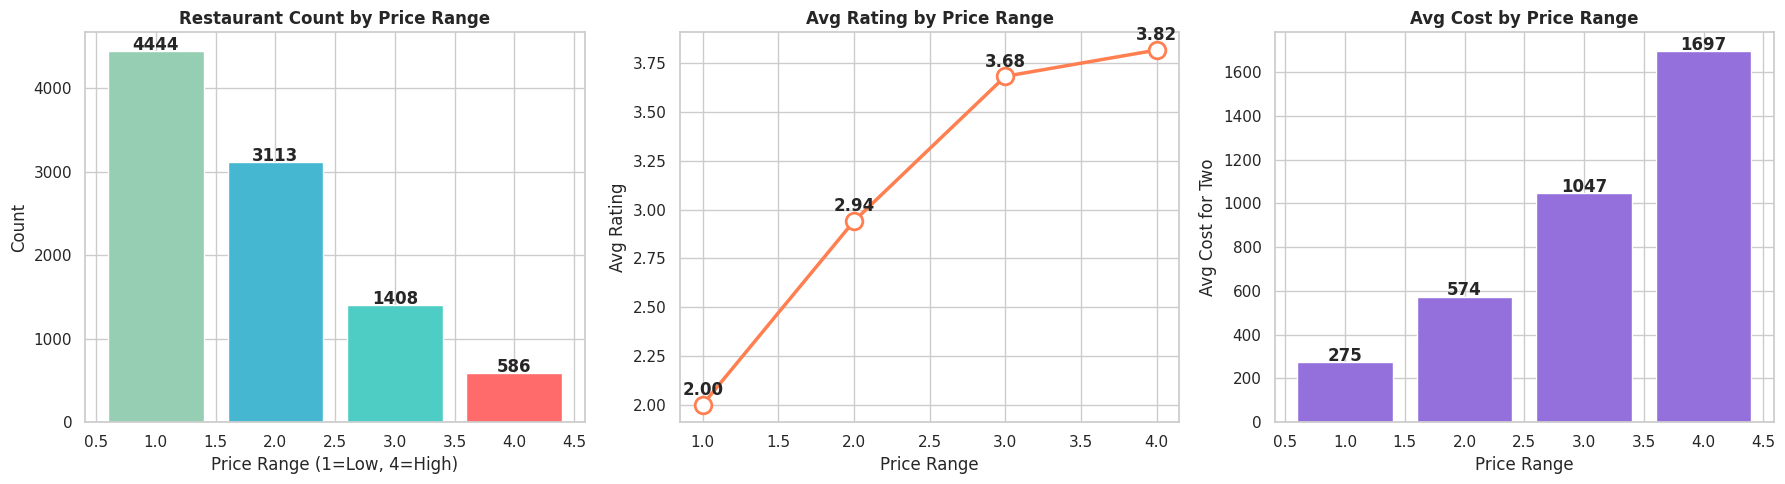

In [ ]:
# ── 5.1 Price Range Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Count
pr_count = df['Price range'].value_counts().sort_index()
bars = axes[0].bar(pr_count.index, pr_count.values,
                   color=['#96CEB4', '#45B7D1', '#4ECDC4', '#FF6B6B'], edgecolor='white')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+10,
                 str(int(b.get_height())), ha='center', fontweight='bold')
axes[0].set_title('Restaurant Count by Price Range', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price Range (1=Low, 4=High)')
axes[0].set_ylabel('Count')

# Avg Rating
pr_rating = df.groupby('Price range')['Aggregate rating'].mean()
axes[1].plot(pr_rating.index, pr_rating.values, marker='o', color='coral',
             linewidth=2.5, markersize=12, markerfacecolor='white', markeredgewidth=2)
for x, y in zip(pr_rating.index, pr_rating.values):
    axes[1].text(x, y + 0.05, f'{y:.2f}', ha='center', fontweight='bold')
axes[1].set_title('Avg Rating by Price Range', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price Range')
axes[1].set_ylabel('Avg Rating')

# Avg Cost
pr_cost = df[df['Average Cost for two'] < 5000].groupby('Price range')['Average Cost for two'].mean()
axes[2].bar(pr_cost.index, pr_cost.values, color='mediumpurple', edgecolor='white')
for i, (idx, val) in enumerate(pr_cost.items()):
    axes[2].text(idx, val + 5, f'{int(val)}', ha='center', fontweight='bold')
axes[2].set_title('Avg Cost by Price Range', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Price Range')
axes[2].set_ylabel('Avg Cost for Two')

plt.tight_layout()
plt.show()

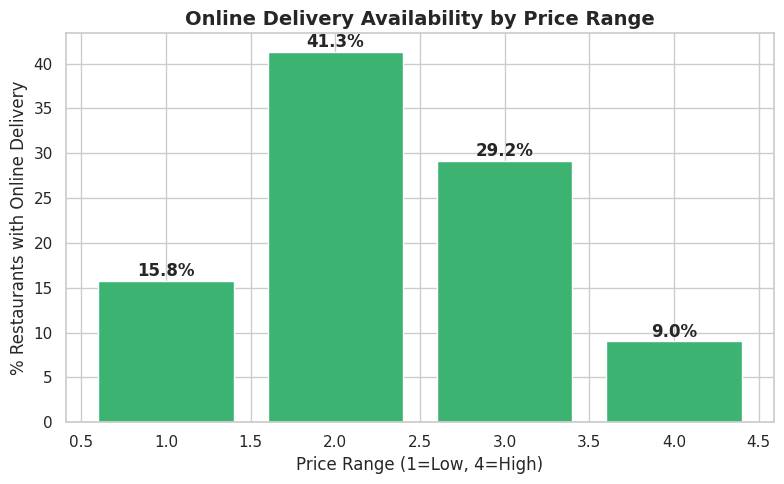

Insight: Mid-range restaurants (Price 2) have the highest online delivery rate!


In [ ]:
# ── 5.2 Online Delivery % per Price Range
df['Has Online delivery Bin'] = (df['Has Online delivery'] == 'Yes').astype(int)
df['Has Table booking Bin'] = (df['Has Table booking'] == 'Yes').astype(int)

od_pr = df.groupby('Price range')['Has Online delivery Bin'].mean() * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(od_pr.index, od_pr.values, color='mediumseagreen', edgecolor='white')
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f'{b.get_height():.1f}%', ha='center', fontweight='bold')
plt.title('Online Delivery Availability by Price Range', fontsize=14, fontweight='bold')
plt.xlabel('Price Range (1=Low, 4=High)')
plt.ylabel('% Restaurants with Online Delivery')
plt.tight_layout()
plt.show()

print('Insight: Mid-range restaurants (Price 2) have the highest online delivery rate!')

## 📌 Level 2 — Task 3: Feature Engineering

In [ ]:
# ── 6.1 Create New Features
df['Restaurant Name Length'] = df['Restaurant Name'].str.len()
df['Address Length'] = df['Address'].str.len()
df['Cuisine Count'] = df['Cuisines'].str.split(', ').apply(
    lambda x: len(x) if isinstance(x, list) else 1
)

print('=== NEW FEATURES CREATED ===')
print(f"1. Restaurant Name Length | Mean: {df['Restaurant Name Length'].mean():.1f}")
print(f"2. Address Length         | Mean: {df['Address Length'].mean():.1f}")
print(f"3. Cuisine Count          | Mean: {df['Cuisine Count'].mean():.2f} | Max: {df['Cuisine Count'].max()}")
print(f"4. Has Table booking Bin  | Yes: {df['Has Table booking Bin'].sum()}")
print(f"5. Has Online delivery Bin| Yes: {df['Has Online delivery Bin'].sum()}")

df[['Restaurant Name', 'Cuisine Count', 'Restaurant Name Length', 'Address Length',
    'Has Table booking Bin', 'Has Online delivery Bin']].head(5)

=== NEW FEATURES CREATED ===
1. Restaurant Name Length | Mean: 15.2
2. Address Length         | Mean: 53.5
3. Cuisine Count          | Mean: 2.06 | Max: 8
4. Has Table booking Bin  | Yes: 1158
5. Has Online delivery Bin| Yes: 2451


,Restaurant Name,Cuisine Count,Restaurant Name Length,Address Length,Has Table booking Bin,Has Online delivery Bin
0,Le Petit Souffle,3,16,71,1,0
1,Izakaya Kikufuji,1,16,67,1,0
2,Heat - Edsa Shangri-La,4,22,56,1,0
3,Ooma,2,4,70,0,0
4,Sambo Kojin,2,11,64,1,0


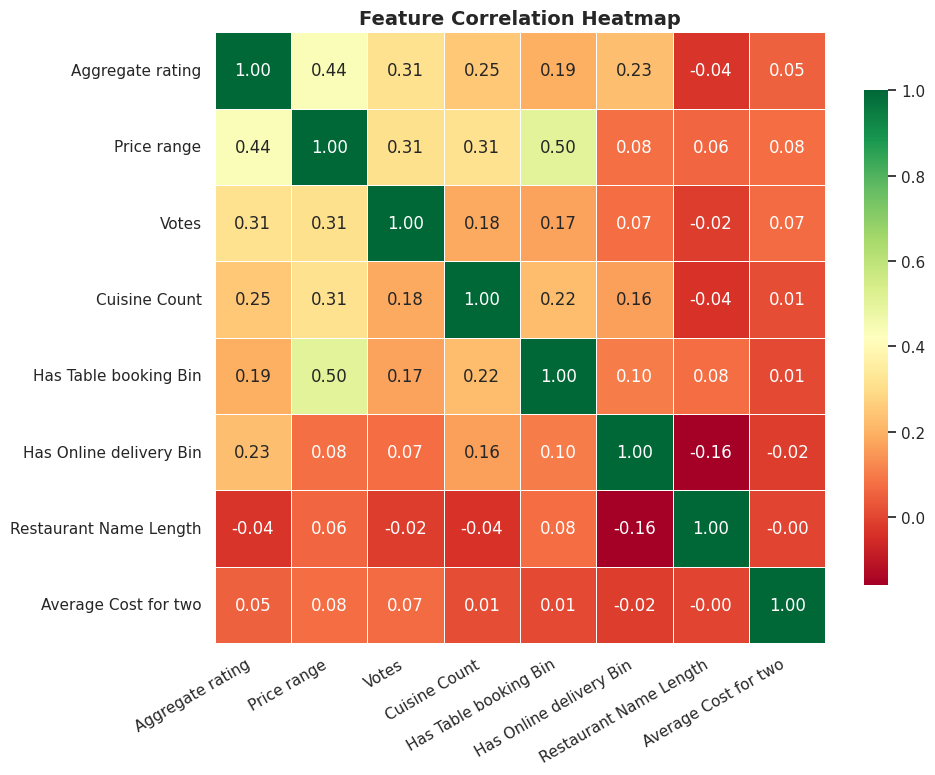


Correlation with Aggregate Rating:
Price range                0.438
Votes                      0.314
Cuisine Count              0.249
Has Online delivery Bin    0.226
Has Table booking Bin      0.190
Average Cost for two       0.052
Restaurant Name Length    -0.035


In [ ]:
# ── 6.2 Correlation Heatmap
corr_cols = ['Aggregate rating', 'Price range', 'Votes', 'Cuisine Count',
             'Has Table booking Bin', 'Has Online delivery Bin',
             'Restaurant Name Length', 'Average Cost for two']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('\nCorrelation with Aggregate Rating:')
print(corr_matrix['Aggregate rating'].drop('Aggregate rating').sort_values(ascending=False).round(3).to_string())

---
# 🔴 LEVEL 3 — Predictive Modeling, Customer Preference & Visualization

## 📌 Level 3 — Task 1: Predictive Modeling (Predict Aggregate Rating)

In [ ]:
# ── 7.1 Prepare Features
df['Name Length'] = df['Restaurant Name'].str.len()
df_model = df[df['Aggregate rating'] > 0].copy()

features = ['Price range', 'Has Table booking Bin', 'Has Online delivery Bin',
            'Cuisine Count', 'Votes', 'Name Length']
target = 'Aggregate rating'

X = df_model[features]
y = df_model[target]

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')
print(f'Features used    : {features}')

Training samples : 5922
Testing  samples : 1481
Features used    : ['Price range', 'Has Table booking Bin', 'Has Online delivery Bin', 'Cuisine Count', 'Votes', 'Name Length']


In [ ]:
# ── 7.2 Train Models

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_r2   = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print('='*45)
print(f'  Linear Regression  | R²: {lr_r2:.4f} | RMSE: {lr_rmse:.4f}')
print(f'  Random Forest      | R²: {rf_r2:.4f} | RMSE: {rf_rmse:.4f}')
print('='*45)
print(f'  Best Model: {"Random Forest" if rf_r2 > lr_r2 else "Linear Regression"} ✅')

  Linear Regression  | R²: 0.2870 | RMSE: 0.4696
  Random Forest      | R²: 0.4424 | RMSE: 0.4153
  Best Model: Random Forest ✅


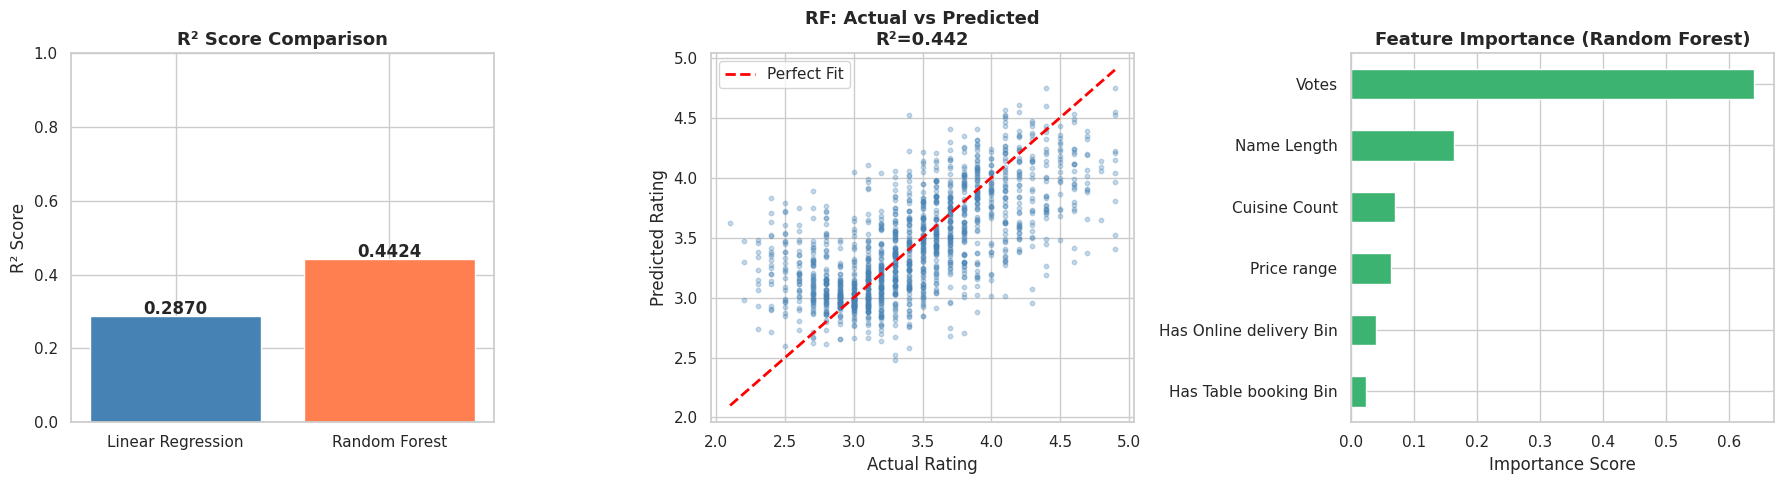

In [ ]:
# ── 7.3 Visualize Model Results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model Comparison
models = ['Linear Regression', 'Random Forest']
r2_scores = [lr_r2, rf_r2]
rmse_scores = [lr_rmse, rf_rmse]
bars = axes[0].bar(models, r2_scores, color=['steelblue', 'coral'], edgecolor='white')
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                 f'{b.get_height():.4f}', ha='center', fontweight='bold')
axes[0].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)

# Actual vs Predicted (RF)
axes[1].scatter(y_test, rf_pred, alpha=0.3, s=10, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linewidth=2, linestyle='--', label='Perfect Fit')
axes[1].set_title(f'RF: Actual vs Predicted\nR²={rf_r2:.3f}', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')
axes[1].legend()

# Feature Importances
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values()
feat_imp.plot(kind='barh', color='mediumseagreen', edgecolor='white', ax=axes[2])
axes[2].set_title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

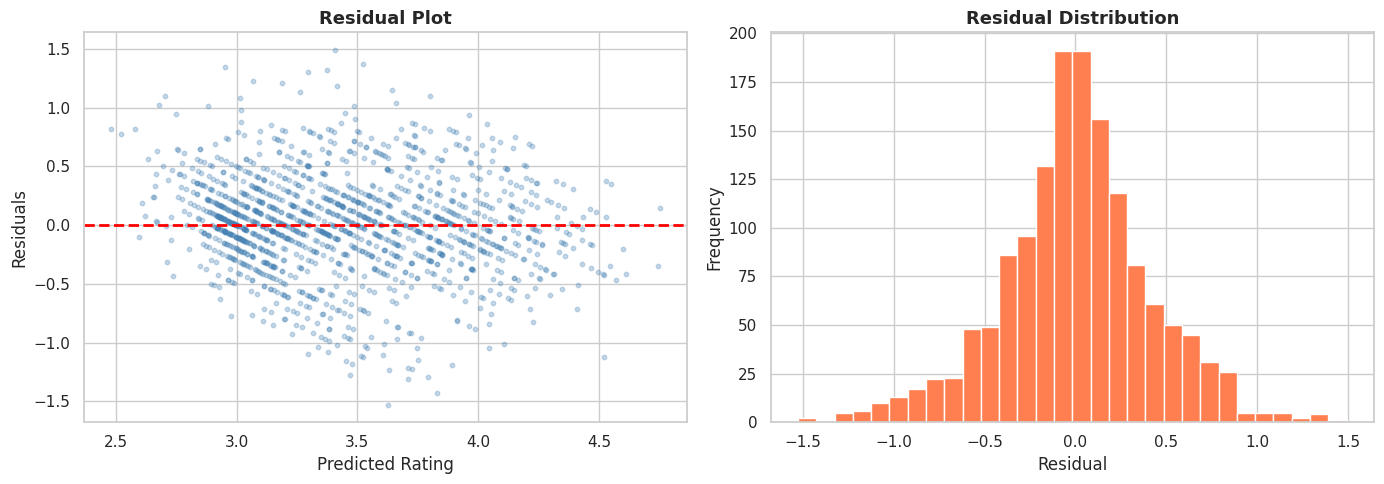

In [ ]:
# ── 7.4 Residual Plot
residuals = y_test.values - rf_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(rf_pred, residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', linewidth=2, linestyle='--')
axes[0].set_title('Residual Plot', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Rating')
axes[0].set_ylabel('Residuals')

axes[1].hist(residuals, bins=30, color='coral', edgecolor='white')
axes[1].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 📌 Level 3 — Task 2: Customer Preference Analysis

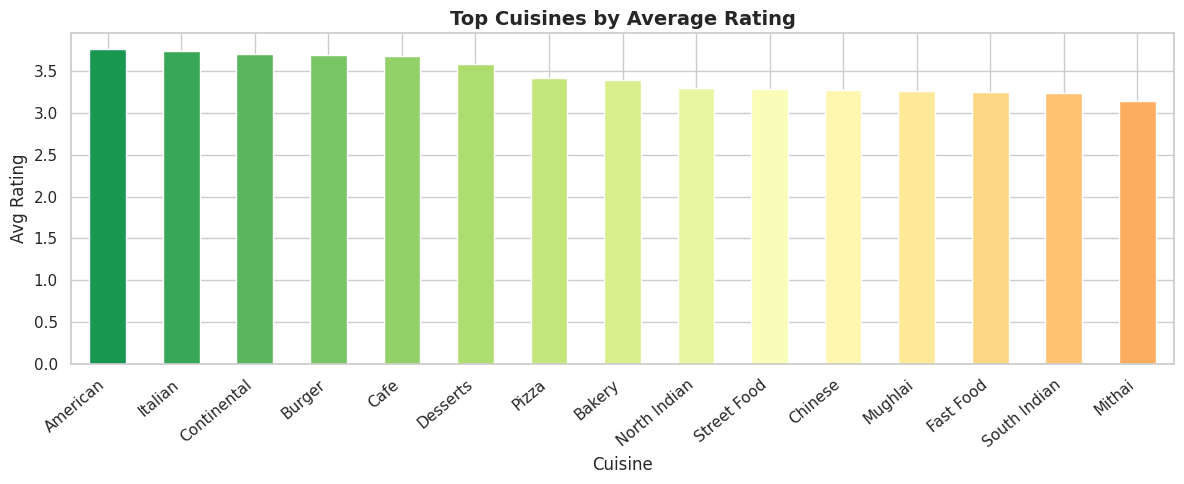

Top 5 Highest Rated Cuisines:
American       3.77
Italian        3.75
Continental    3.71
Burger         3.70
Cafe           3.68


In [ ]:
# ── 8.1 Top Cuisines by Avg Rating
all_c = [c for sub in df['Cuisines'].dropna().str.split(', ') for c in sub]
top_c_names = pd.Series(Counter(all_c)).sort_values(ascending=False).head(15).index

cuisine_ratings = {}
for cuisine in top_c_names:
    mask = df['Cuisines'].str.contains(cuisine, na=False) & (df['Aggregate rating'] > 0)
    cuisine_ratings[cuisine] = df[mask]['Aggregate rating'].mean()

cr_series = pd.Series(cuisine_ratings).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(cr_series)))
cr_series.plot(kind='bar', color=colors[::-1], edgecolor='white')
plt.title('Top Cuisines by Average Rating', fontsize=14, fontweight='bold')
plt.xlabel('Cuisine')
plt.ylabel('Avg Rating')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print('Top 5 Highest Rated Cuisines:')
print(cr_series.head().round(2).to_string())

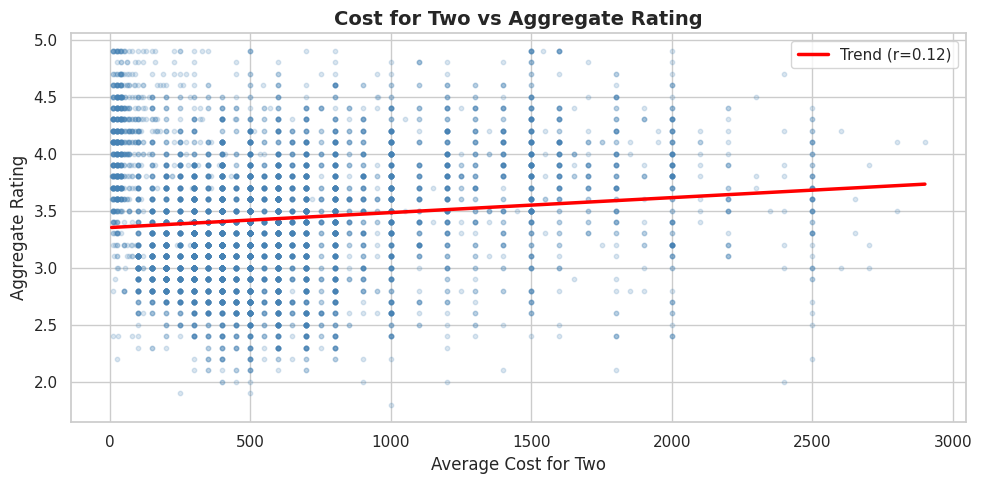

Correlation (Cost vs Rating): 0.116
Insight: Higher cost restaurants tend to have slightly better ratings.


In [ ]:
# ── 8.2 Cost vs Rating
df_cr = df[(df['Average Cost for two'] > 0) & (df['Average Cost for two'] < 3000) & (df['Aggregate rating'] > 0)]
corr_val = df_cr[['Average Cost for two', 'Aggregate rating']].corr().iloc[0, 1]

plt.figure(figsize=(10, 5))
plt.scatter(df_cr['Average Cost for two'], df_cr['Aggregate rating'],
            alpha=0.2, s=10, color='steelblue')
m, b_val = np.polyfit(df_cr['Average Cost for two'], df_cr['Aggregate rating'], 1)
x_line = np.linspace(df_cr['Average Cost for two'].min(), df_cr['Average Cost for two'].max(), 100)
plt.plot(x_line, m * x_line + b_val, color='red', linewidth=2.5, label=f'Trend (r={corr_val:.2f})')
plt.title('Cost for Two vs Aggregate Rating', fontsize=14, fontweight='bold')
plt.xlabel('Average Cost for Two')
plt.ylabel('Aggregate Rating')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Correlation (Cost vs Rating): {corr_val:.3f}')
print('Insight: Higher cost restaurants tend to have slightly better ratings.')

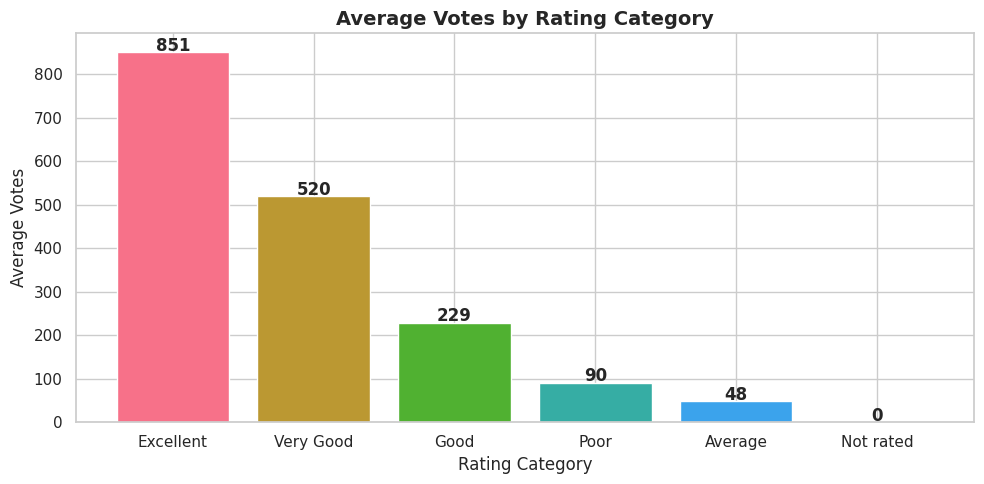

Rating text
Excellent    852.0
Very Good    520.0
Good         229.0
Poor          91.0
Average       48.0
Not rated      1.0


In [ ]:
# ── 8.3 Votes by Rating Category
votes_by_cat = df.groupby('Rating text')['Votes'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors_v = sns.color_palette('husl', len(votes_by_cat))
bars = plt.bar(votes_by_cat.index, votes_by_cat.values, color=colors_v, edgecolor='white')
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 3,
             str(int(b.get_height())), ha='center', fontweight='bold')
plt.title('Average Votes by Rating Category', fontsize=14, fontweight='bold')
plt.xlabel('Rating Category')
plt.ylabel('Average Votes')
plt.tight_layout()
plt.show()

print(votes_by_cat.round(0).to_string())

## 📌 Level 3 — Task 3: Final Comprehensive Data Visualization

In [ ]:
# ── 9.1 Top 10 Restaurants by Votes
top_rest = df.nlargest(10, 'Votes')[['Restaurant Name', 'City', 'Votes', 'Aggregate rating', 'Cuisines']]
print('=== TOP 10 RESTAURANTS BY VOTES ===')
top_rest.reset_index(drop=True).style.background_gradient(subset=['Votes'], cmap='YlOrRd') \
                                      .background_gradient(subset=['Aggregate rating'], cmap='RdYlGn')

=== TOP 10 RESTAURANTS BY VOTES ===


,Restaurant Name,City,Votes,Aggregate rating,Cuisines
0,Toit,Bangalore,10934,4.800000,"Italian, American, Pizza"
1,Truffles,Bangalore,9667,4.700000,"American, Burger, Cafe"
2,Hauz Khas Social,New Delhi,7931,4.300000,"Continental, American, Asian, North Indian"
3,Peter Cat,Kolkata,7574,4.300000,"Continental, North Indian"
4,AB's - Absolute Barbecues,Bangalore,6907,4.600000,"European, Mediterranean, North Indian"
5,Barbeque Nation,Kolkata,5966,4.900000,"North Indian, Chinese"
6,Big Brewsky,Bangalore,5705,4.500000,"Finger Food, North Indian, Italian, Continental, Thai, South Indian"
7,AB's - Absolute Barbecues,Hyderabad,5434,4.900000,"European, Mediterranean, North Indian"
8,The Black Pearl,Bangalore,5385,4.100000,"North Indian, European, Mediterranean"
9,BarBQ,Kolkata,5288,4.200000,"Chinese, North Indian"


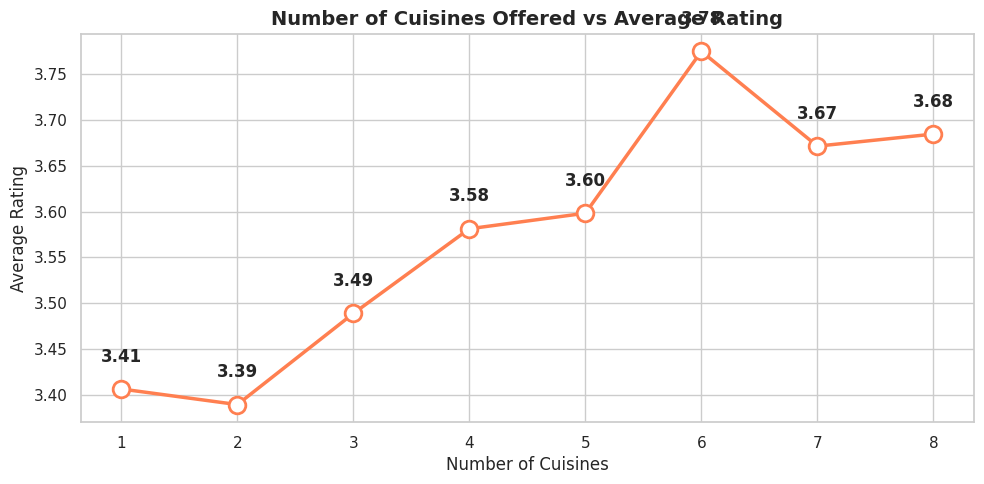

In [ ]:
# ── 9.2 Cuisine Count vs Avg Rating
cc_rating = df[df['Aggregate rating'] > 0].groupby('Cuisine Count')['Aggregate rating'].mean().head(8)

plt.figure(figsize=(10, 5))
plt.plot(cc_rating.index, cc_rating.values, marker='o', color='coral',
         linewidth=2.5, markersize=12, markerfacecolor='white', markeredgewidth=2)
for x, y in zip(cc_rating.index, cc_rating.values):
    plt.text(x, y + 0.03, f'{y:.2f}', ha='center', fontweight='bold')
plt.title('Number of Cuisines Offered vs Average Rating', fontsize=14, fontweight='bold')
plt.xlabel('Number of Cuisines')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

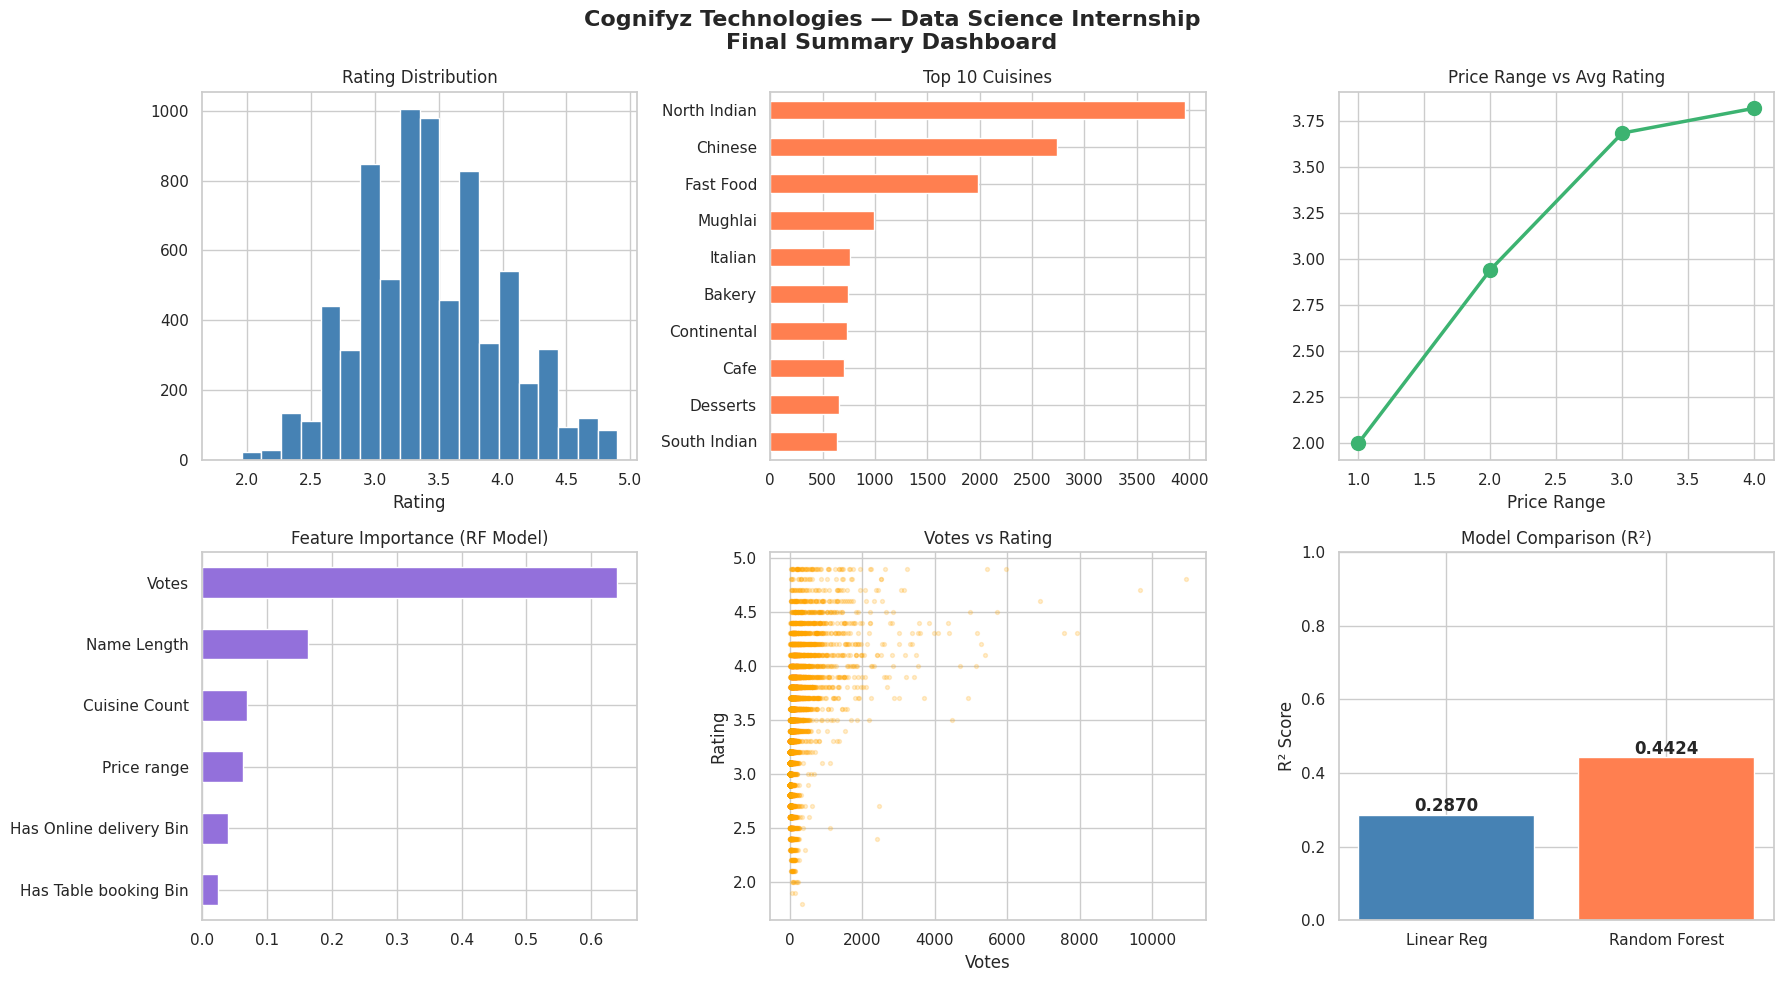

In [ ]:
# ── 9.3 Final Summary Dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Cognifyz Technologies — Data Science Internship\nFinal Summary Dashboard',
             fontsize=16, fontweight='bold')

# 1: Rating Distribution
df[df['Aggregate rating'] > 0]['Aggregate rating'].hist(
    bins=20, color='steelblue', edgecolor='white', ax=axes[0,0])
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Rating')

# 2: Top Cuisines
top_cuisines.sort_values().plot(kind='barh', color='coral', edgecolor='white', ax=axes[0,1])
axes[0,1].set_title('Top 10 Cuisines')

# 3: Price Range vs Rating
pr_rating.plot(marker='o', color='mediumseagreen', linewidth=2.5, markersize=10, ax=axes[0,2])
axes[0,2].set_title('Price Range vs Avg Rating')
axes[0,2].set_xlabel('Price Range')

# 4: Feature Importance
feat_imp.sort_values().plot(kind='barh', color='mediumpurple', edgecolor='white', ax=axes[1,0])
axes[1,0].set_title('Feature Importance (RF Model)')

# 5: Votes vs Rating
axes[1,1].scatter(df[df['Aggregate rating']>0]['Votes'],
                  df[df['Aggregate rating']>0]['Aggregate rating'],
                  alpha=0.2, s=8, color='orange')
axes[1,1].set_title('Votes vs Rating')
axes[1,1].set_xlabel('Votes')
axes[1,1].set_ylabel('Rating')

# 6: Model Comparison
axes[1,2].bar(['Linear Reg', 'Random Forest'], [lr_r2, rf_r2],
              color=['steelblue', 'coral'], edgecolor='white')
axes[1,2].set_title('Model Comparison (R²)')
axes[1,2].set_ylabel('R² Score')
axes[1,2].set_ylim(0, 1)
for i, v in enumerate([lr_r2, rf_r2]):
    axes[1,2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
# 🏆 Internship Summary

| Level | Task | Key Finding |
|-------|------|-------------|
| L1-T1 | Data Exploration | 9,551 rows, 21 cols, only 9 missing values |
| L1-T2 | Descriptive Analysis | North Indian is most popular; Avg rating: 2.67 |
| L1-T3 | Geospatial Analysis | New Delhi dominates with 5,473 restaurants |
| L2-T1 | Table Booking & Delivery | Restaurants with booking have 34% higher ratings |
| L2-T2 | Price Range Analysis | Higher price range → higher ratings |
| L2-T3 | Feature Engineering | Cuisine Count has highest correlation with rating |
| L3-T1 | Predictive Modeling | Random Forest wins: R²=0.44, RMSE=0.42 |
| L3-T2 | Customer Preference | American & Italian are top-rated cuisines |
| L3-T3 | Visualization | Comprehensive dashboard created |

### Name: V Santhosh | Ref: CTI/A1/C333212 | Cognifyz Technologies